# prep

In [ ]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [ ]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

Mounted at /content/drive/


In [ ]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [ ]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

In [ ]:
from scipy.interpolate import interp1d
def resample_to_max_length(list_of_arrays):
    max_len = max(len(arr) for arr in list_of_arrays)
    resampled = []
    for arr in list_of_arrays:
        x_old = np.linspace(0, 1, len(arr))
        x_new = np.linspace(0, 1, max_len)
        f = interp1d(x_old, arr, kind='linear', fill_value='extrapolate')
        resampled.append(f(x_new))
    return np.array(resampled), max_len

## config

In [ ]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [ ]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v7/csvs/'

# Data: loom

In [ ]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1zJNHJJECC8FGB9S8tIh6QnoRihyoTZyKAgS-SE8ojwU/edit?gid=1421697431#gid=1421697431'
tab_name = 'loom_gsize'

experiment_class = 'Loom escape - group size'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class
data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

,experiment,fish_num,rig_mm,vid_px,rig_coord,loomX,loomZ,loom_dur
0,jy_240311_s16,1,265,945,"25,27;981,27;981,977;25,977",15,-30,6
1,jy_240311_s18,1,265,945,"25,27;981,27;981,977;25,977",15,-30,4
2,jy_240318_s20,1,265,927,"28,43;967,43;967,977;28,977",-15,30,5
3,jy_240318_s21,1,265,927,"28,43;967,43;967,977;28,977",-15,-30,3
4,jy_240318_s22,1,265,927,"28,43;967,43;967,977;28,977",-15,30,4
...,...,...,...,...,...,...,...,...
93,jy_240516_s10,8,265,904,"48,51;965,51;965,955;48,955",15,-30,3
94,jy_240516_s11,8,265,904,"48,51;965,51;965,955;48,955",15,30,3
95,jy_240516_s12,8,265,904,"48,51;965,51;965,955;48,955",-15,-30,3
96,jy_240516_s13,8,265,904,"48,51;965,51;965,955;48,955",-15,30,5


# S4a - example loom angles within group

jy_240318_s15: 6 fish
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4a


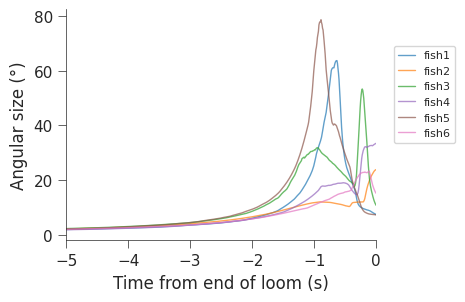

,f1,f2,f3,f4,f5,f6
0,1.953669,2.162362,2.279600,1.846308,2.096570,2.028010
1,1.957037,2.166290,2.284040,1.849235,2.101320,2.031548
2,1.960370,2.169579,2.288490,1.852157,2.106073,2.035171
3,1.963704,2.172906,2.293003,1.855097,2.110823,2.038752
4,1.967595,2.176211,2.297525,1.858039,2.115595,2.042326
...,...,...,...,...,...,...
597,7.824042,23.211798,12.506444,33.040648,7.409627,16.666503
598,7.718024,23.468338,11.992092,33.140404,7.393786,16.185111
599,7.613747,23.631877,11.522318,33.275145,7.357317,15.814872
600,7.513352,23.784402,11.124816,33.353111,7.305369,15.480213


In [ ]:
subpanel = 'S4a'
rep_experiments = ['jy_240318_s15']
samples = [] # for csv saving

for exp in rep_experiments:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  # make time_sec relative to tap for plotting
  rel_time = np.linspace(0-(loom_len/fps),0,loom_len); rel_sec = np.round(rel_time,2)

  # vis
  print(f'{exp}: {fish_num} fish')
  plt.figure(figsize=[4,3])
  for f in range(fish_num):
    plt.plot(rel_time,loom_subtend_angle[f],alpha=0.7,label=f'fish{f+1}',lw=1)
    samples.append(loom_subtend_angle[f])
  plt.ylabel('Angular size (°)'); plt.xlabel('Time from end of loom (s)')
  plt.xlim(-1*loom_dur,0);
  plt.legend(bbox_to_anchor=(1.05,0.85),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=8)
  sns.despine();
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
  plt.show()

# save source data into csv - for time series, save out the visible part
series_dict = {}
for i, sample in enumerate(samples):
  col_name = f"f{i+1}"
  series_dict[col_name] = pd.Series(sample)  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S4b - speed aligned by threshold, by loom speed

['#f778a6', '#ef589e', '#de3797', '#c31789', '#a6017c', '#850178', '#660071', '#49006a']


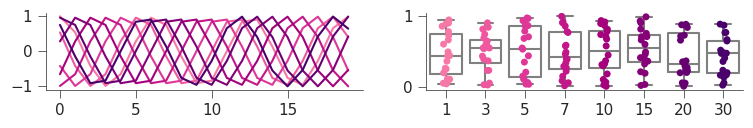

In [ ]:
# RGB hex values theme - for summary stats plots
group_names = [1,3,5,7,10,15,20,30]; group_num = len(group_names)

# get the RGBA from normalized colormap axis
viridis_colors = [cm.RdPu(i/(group_num+5)) for i in range(6,group_num+6)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

In [ ]:
# some stats to calculate loom approach L/V
radius = 4.3 # cm
displacement = np.sqrt((30)**2+(15)**2)


Loom_dur = 3
['1°: N=126', '3°: N=126', '5°: N=125', '7°: N=118', '10°: N=76', '15°: N=41', '20°: N=30', '30°: N=13']
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4b-3


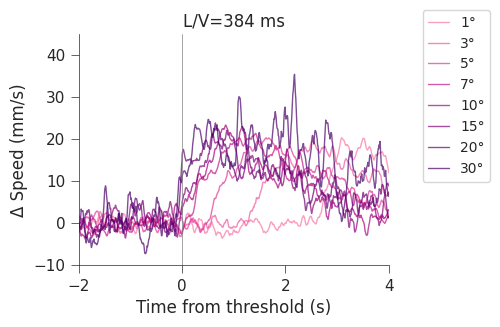

,1°_1,1°_2,1°_3,1°_4,1°_5,1°_6,1°_7,1°_8,1°_9,1°_10,...,30°_4,30°_5,30°_6,30°_7,30°_8,30°_9,30°_10,30°_11,30°_12,30°_13
0,1.263536,-5.290548,-11.729714,18.314356,-10.334197,30.796098,3.067225,-18.006269,12.291609,7.803099,...,-2.774923,-9.884028,-17.135320,-18.112699,-3.867459,-23.080097,29.218982,-7.799707,23.643572,-12.493613
1,5.784322,-5.185127,-10.696829,14.675603,-7.439244,34.304275,1.841822,-19.081864,11.830224,6.504860,...,-5.107603,-9.466891,-17.113045,-16.758046,11.541931,-27.063212,29.054755,-7.992242,25.247985,-12.404451
2,15.536897,-4.616926,-10.780907,13.613532,-4.393598,36.883951,-0.011776,-19.643742,11.009692,4.523593,...,-6.885988,-7.034155,-18.057113,-16.323203,10.589070,-28.522053,28.134593,-8.449207,25.459313,-12.039492
3,29.541463,-3.759273,-11.659638,13.003569,-1.002376,38.535125,-2.217949,-21.384558,9.830013,4.096106,...,-6.475303,-3.339476,-4.176668,-15.907400,11.036835,-29.121914,26.458496,-8.841626,24.277556,-11.936616
4,30.341356,-2.562123,-11.764385,11.803220,2.734422,37.560785,-3.399889,-23.416571,5.756509,2.720894,...,-6.979120,1.659464,5.165656,-15.091920,10.308673,-28.937015,24.026464,-8.667969,21.702714,-11.662546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,-1.461738,44.878847,68.629037,96.367521,-11.724029,-13.492438,-18.437440,13.225796,2.472476,9.600340,...,48.718394,27.341477,-6.058584,13.633428,-22.465842,-28.071582,13.332796,5.052808,-3.283561,-13.197956
722,-0.440273,46.856006,68.179253,89.763960,-12.121022,-14.377507,-17.675676,13.202089,3.063060,9.600340,...,45.553564,25.951044,-5.984319,11.850075,-23.149033,-28.311677,12.477955,4.270262,-4.055693,-13.186689
723,0.513789,48.638000,67.729470,82.365280,-13.816924,-13.776130,-17.791742,13.062842,3.653644,9.600340,...,42.388735,24.130074,-6.143960,10.146170,-21.997471,-28.451735,10.677750,1.753176,-4.139682,-13.050696
724,1.400447,51.327101,67.279686,74.171482,-14.913331,-13.911360,-17.848644,12.923595,4.244227,9.600340,...,39.223905,21.878565,-6.031937,8.521713,-21.568680,-27.876422,7.932182,0.466065,-3.862651,-12.884880



Loom_dur = 4
['1°: N=96', '3°: N=96', '5°: N=96', '7°: N=81', '10°: N=60', '15°: N=37', '20°: N=23', '30°: N=13']
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4b-4


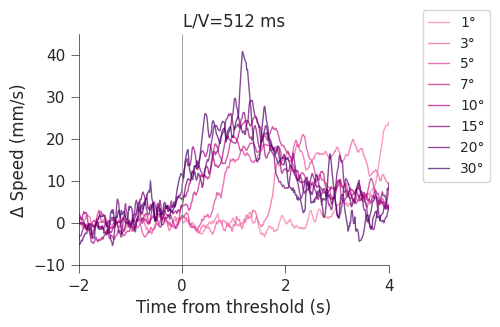

,1°_1,1°_2,1°_3,1°_4,1°_5,1°_6,1°_7,1°_8,1°_9,1°_10,...,30°_4,30°_5,30°_6,30°_7,30°_8,30°_9,30°_10,30°_11,30°_12,30°_13
0,27.137626,-1.151295,-1.221066,-5.489458,-2.585702,-3.836103,-8.015882,-8.241860,9.110928,-22.632529,...,-20.122476,-5.588127,1.061271,-5.451521,-1.408202,0.668379,-6.196503,2.148242,-6.569037,-7.751349
1,24.920497,-1.418668,-1.492654,-5.977320,0.543921,-3.359729,-9.618286,-8.149996,9.127332,-22.668303,...,-21.667603,-4.931380,3.871900,-6.175377,-1.186288,1.190161,-6.299676,2.992773,-6.801842,-7.511918
2,22.470081,-2.040786,-1.581910,-5.299083,4.195560,-1.660416,-11.062099,-6.790774,9.237827,-22.648752,...,-21.845241,-6.621996,6.350418,-5.694665,-0.916795,1.054820,-6.370958,2.470814,-7.032129,-6.901773
3,20.618789,-2.993103,-0.753269,-5.491754,7.670693,-1.571594,-10.794393,-3.855275,8.908929,-22.001513,...,-22.516579,-7.497777,7.321705,-4.938190,-0.984911,0.895870,-6.400088,1.756448,-7.785239,-6.542540
4,19.366621,-2.864711,-0.200060,-4.945890,10.822931,-1.997123,-10.075889,1.196822,8.910734,-21.309091,...,-22.496535,-7.558725,6.815931,-4.625146,0.457051,1.338915,-6.498260,1.605185,-7.675336,-5.382881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,-19.118473,67.543698,51.369519,28.491863,-6.530178,47.674118,-10.529327,32.009318,-1.396703,-4.269346,...,-24.270149,-6.200253,19.194673,28.447909,-4.297659,24.967698,-2.972506,-7.077994,-8.537577,-9.253815
722,-18.957933,68.952148,44.894412,29.922390,-5.563636,44.261032,-8.338961,29.444704,-1.517634,-4.023654,...,-7.776971,5.968567,17.780652,31.196270,-4.692192,27.957110,-2.063917,-7.553175,-7.984828,-9.149826
723,-19.192586,70.360598,41.008081,31.352916,-5.052798,41.740762,-5.797362,27.083376,-1.638565,-3.777961,...,-8.208781,5.459370,15.358024,32.667644,-5.145136,27.786913,-2.053924,-7.438781,-7.835021,-9.199635
724,-19.341847,70.761972,39.710526,32.783442,-3.665757,38.476645,-3.214414,24.925334,-1.759497,-3.532268,...,7.895282,4.408590,11.781764,33.816282,-4.774167,24.469720,-1.886515,-7.092329,-7.838767,-10.007972



Loom_dur = 5
['1°: N=72', '3°: N=72', '5°: N=72', '7°: N=67', '10°: N=50', '15°: N=35', '20°: N=33', '30°: N=22']
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4b-5


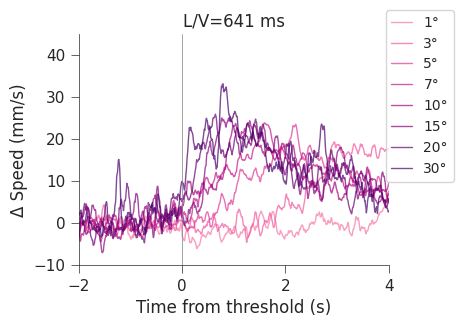

,1°_1,1°_2,1°_3,1°_4,1°_5,1°_6,1°_7,1°_8,1°_9,1°_10,...,30°_13,30°_14,30°_15,30°_16,30°_17,30°_18,30°_19,30°_20,30°_21,30°_22
0,1.312170,3.696352,10.961376,-3.024521,58.783018,-22.844897,32.896983,-7.811173,5.591241,10.130947,...,-17.007810,-16.506973,-12.023220,24.957746,-9.368266,38.276378,-5.656917,20.172583,36.258597,6.921804
1,1.609778,5.256001,9.200790,-0.201263,44.735391,-22.491894,32.583941,8.006372,4.298700,9.850814,...,-17.290854,-17.902940,-12.205128,27.130104,-9.938341,33.134005,-6.434859,17.239357,40.566194,8.779673
2,2.295075,5.999538,7.329398,4.941173,30.107546,-22.750744,18.255291,23.905068,3.534227,7.711034,...,-16.916337,-19.063178,-12.291768,28.184873,-10.067918,22.727126,-6.733370,15.344450,44.854484,10.446965
3,3.368061,3.959028,6.837275,12.168714,15.172066,-23.650931,4.075015,24.705435,3.563028,6.789227,...,-8.249544,-18.821147,-12.291147,27.738348,-10.147706,6.260712,-7.612391,13.824440,46.326082,12.137121
4,2.584635,3.010638,7.686992,19.347412,-0.842424,-7.675623,4.498339,23.933388,1.954666,5.871010,...,8.570038,-18.550833,-12.033034,11.986301,-10.177704,5.212192,-7.520406,12.389579,44.980990,13.189163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,33.565395,-4.015867,4.534362,8.379901,23.736005,7.832881,12.112795,26.288480,-5.965908,-3.496857,...,18.048792,8.422312,-13.076762,-4.397149,-12.219359,8.142923,6.982650,-1.310227,42.464197,5.849224
722,35.358662,-3.212468,3.316372,10.007964,10.769574,9.432339,12.636699,39.726389,-5.850629,-3.824759,...,18.068165,5.900008,-12.997581,-5.658223,-12.656718,9.053734,7.921309,-2.239037,44.603471,7.212136
723,38.657033,-2.770223,3.600205,11.390393,11.067594,24.599282,12.312251,38.639303,-6.105045,-3.780551,...,18.046451,5.309332,-12.890195,-5.244927,-12.795321,10.330509,6.170590,-4.039997,46.592037,7.913804
724,43.460509,-2.064240,3.194289,12.527187,-1.087390,39.285647,12.866785,38.376342,-5.937421,-4.247894,...,14.771038,3.801853,-12.833254,-5.113223,-12.527791,9.156882,4.408712,-5.766836,47.725043,9.060832



Loom_dur = 6
['1°: N=82', '3°: N=82', '5°: N=81', '7°: N=67', '10°: N=44', '15°: N=28', '20°: N=16', '30°: N=10']
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4b-6


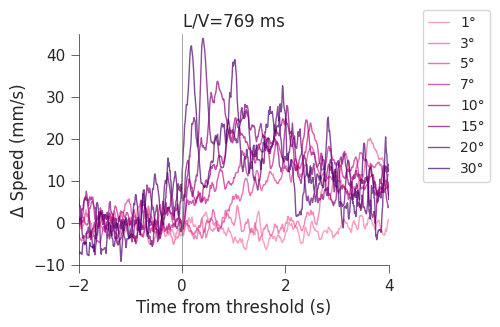

,1°_1,1°_2,1°_3,1°_4,1°_5,1°_6,1°_7,1°_8,1°_9,1°_10,...,30°_1,30°_2,30°_3,30°_4,30°_5,30°_6,30°_7,30°_8,30°_9,30°_10
0,99.423419,10.146560,-5.946822,-19.396050,8.761441,19.768862,18.623840,-9.234650,19.622157,-4.704462,...,-21.627919,-24.010571,-7.221929,-18.801169,-0.409190,24.379392,-6.443971,6.833527,-8.352517,-14.257905
1,109.643676,0.544262,-7.771036,-19.593777,8.705054,20.686701,17.046572,6.400886,23.183739,-5.074464,...,-21.480078,-23.068277,-6.764199,-18.703197,-0.768178,25.807046,-7.785012,3.886938,-8.781268,-14.377606
2,106.219294,-16.698263,-8.736743,-19.836531,8.804147,3.519602,15.326016,14.022635,25.754382,-4.906455,...,-21.351733,-21.939467,-5.978525,-17.729865,-0.628893,26.800407,-8.008715,2.047005,-8.899627,-14.704831
3,89.150273,-17.981136,-9.353597,-19.648139,8.839952,-13.747396,13.970391,13.630596,27.309552,-3.677571,...,-20.545437,-20.676449,-6.059581,-17.481784,-1.017788,27.359477,-7.671515,1.247369,-9.315252,-14.905834
4,74.598925,-19.551076,-10.461507,-19.756134,8.355121,-13.902374,12.442103,13.620352,27.700011,-2.514103,...,-21.306346,-20.403824,-6.442043,-17.083263,-1.383202,27.484253,-6.034063,1.328985,-10.229319,-15.284945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,0.703628,-20.095201,-16.820849,3.532469,-23.529245,-15.687150,-8.265903,-9.815381,-14.301983,3.485996,...,4.571527,-25.092406,62.001466,49.301914,26.751584,-25.085851,25.473648,1.244046,9.652354,34.709550
722,0.589580,-20.315345,-17.169470,12.436687,-23.365078,-15.559037,-8.410078,-10.469723,-14.220939,3.488517,...,1.989885,-25.308960,61.366001,33.629259,28.098791,-23.403258,26.178368,3.962703,-3.565305,33.092695
723,0.071123,-22.221794,-17.391830,15.373771,-23.310543,-15.502444,-7.616319,-10.802023,-14.105559,3.871354,...,0.092553,-25.360657,58.344128,17.716391,29.968490,-21.925576,26.883088,6.613555,-2.208781,31.652516
724,-0.440713,-23.774750,-17.852886,18.974073,-23.495640,-14.775478,-6.809358,-10.812280,-13.995162,3.755330,...,-3.053272,-9.873459,52.508071,17.550276,32.360679,-20.171724,27.587808,11.594308,-0.424083,29.716935


In [ ]:
subpanels = ['S4b','S4b','S4b','S4b']
loom_speeds = [3,4,5,6]

for subpanel, spd in zip(subpanels,loom_speeds):
  print(f'\nLoom_dur = {spd}')
  loom_thresholds = [1,3,5,7,10,15,20,30]
  speed_mm_baseline = {n:[] for n in loom_thresholds};

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
    if fish_num <4: continue
    if loom_dur != spd: continue
    speed = displacement/loom_dur # cm/s
    SSR = (radius/speed)*1000 # ms

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed = data['f_speed']*scale
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
    data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
    loom_subtend_angle = data['loom_subtend_angle']

    for loom_threshold in loom_thresholds:
      for f in range(fish_num):
        cross_loom_idx = np.where(loom_subtend_angle[f]>loom_threshold)[0]
        if len(cross_loom_idx) == 0: continue # skip fish whose viewing never cross critical threshold
        align_idx = int(loom_on + cross_loom_idx[0])

        # Calculate baseline-subtracted speed
        baseline_speed = np.mean(f_speed[f][align_idx-int(6*121):align_idx])
        speed_baseline_norm = f_speed[f][align_idx-int(6*121):align_idx+int(6*121)] - baseline_speed
        speed_mm_baseline[loom_threshold].append(speed_baseline_norm)

  # make time_sec relative to tap for plotting
  pre = np.linspace(-6,0,6*121); post = np.linspace(0,6,6*121)
  rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

  metric = speed_mm_baseline
  print([f"{gs}°: N={len(speed_mm_baseline[gs])}" for gs in loom_thresholds])
  plt.figure(figsize=[3,3])
  for ithreshold, loom_threshold in enumerate(loom_thresholds):
    plt.plot(rel_time,np.mean(metric[loom_threshold],axis=0),c=hex_colors[ithreshold],lw=1,alpha=0.7,label=f"{loom_threshold}°")
  plt.xlim(-2,4); plt.xticks([-2,0,2,4]);
  plt.ylabel('Δ Speed (mm/s)'); plt.xlabel('Time from threshold (s)')
  plt.axvline(0,c='grey',linewidth=0.5); plt.ylim(-10,45)
  plt.legend(bbox_to_anchor=(1.1,0.35),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
  sns.despine(); plt.title(f'L/V={int(SSR)} ms')
  print(figure_path+subpanel+f'-{spd}')
  plt.savefig(figure_path+subpanel+f"-{spd}.pdf",bbox_inches='tight');
  plt.show()

  # save source data into csv - for time series, save out the visible part
  ST, ED = -6, 6; st, ed = -2, 4; fps = 121

  series_dict = {}
  for group, samples in speed_mm_baseline.items():
    for i, sample in enumerate(samples):
      col_name = f"{group}°_{i+1}"
      series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'-{spd}.csv', index=False)

# S4c - max loom angle PDF

N, 25, 50, and 75th percentile:
(N=376) [ 8.33811088 11.56686079 21.59674901]
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4c


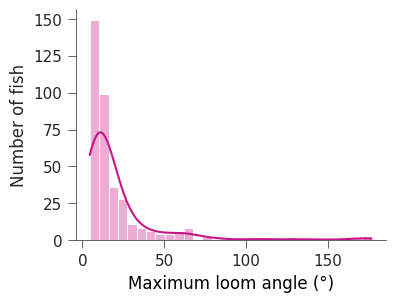

,max loom angle
0,6.822676
1,10.542230
2,12.155791
3,9.945738
4,9.490534
...,...
371,21.837672
372,18.696648
373,35.451904
374,25.731686


In [ ]:
subpanel = 'S4c'

all_max_angles = []
for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  if fish_num <4: continue # restrict to groups of 4 or larger

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  for f in range(fish_num):
    # Maximum loom angle for this fish
    max_angle = np.nanmax(loom_subtend_angle[f])
    all_max_angles.append(max_angle)

# descriptive stats
data = all_max_angles
print("N, 25, 50, and 75th percentile:")
print(f"(N={len(data)}) {np.percentile(data, [25,50,75])}")

# plot
plt.figure(figsize=[4,3])
sns.histplot(all_max_angles, bins=30, alpha=0.35, color='mediumvioletred', kde=True, edgecolor='white')
plt.xlabel('Maximum loom angle (°)', fontsize=12, color='black')
plt.ylabel('Number of fish');
sns.despine()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf", bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {'max loom angle': all_max_angles}
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S4d - max loom angle PDF (by loom speed)

['#000000', '#333333', '#666666', '#999999']


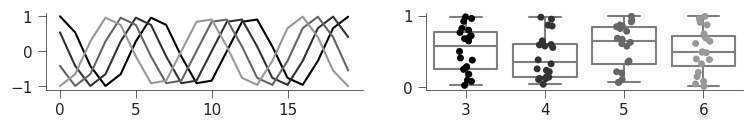

In [ ]:
group_names = [3,4,5,6]; group_num = len(group_names)
# get the RGBA from normalized colormap axis
viridis_colors = [cm.gist_gray(i/(group_num+1)) for i in range(0,group_num)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']
# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

In [ ]:
# some stats to calculate loom approach L/V
radius = 4.3 # cm
displacement = np.sqrt((30)**2+(15)**2)


Loom_dur = 3
N, 25, 50, and 75th percentile:
(N=126) [ 8.27315922 11.26415842 18.09384454]

Loom_dur = 4
N, 25, 50, and 75th percentile:
(N=96) [ 8.07862743 12.27303163 19.67073889]

Loom_dur = 5
N, 25, 50, and 75th percentile:
(N=72) [ 9.55879955 13.52237839 35.63137965]

Loom_dur = 6
N, 25, 50, and 75th percentile:
(N=82) [ 7.99327567 10.46855874 16.51329031]
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4d


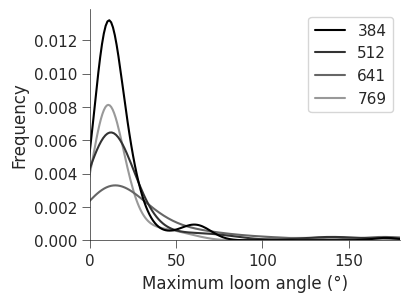

,L/V_384.60369212996386ms,L/V_512.8049228399518ms,L/V_641.0061535499398ms,L/V_769.2073842599277ms
0,6.822676,8.870772,9.490534,14.917529
1,10.542230,63.804935,5.703861,6.694594
2,12.155791,25.329671,10.327340,7.605328
3,9.945738,139.858995,6.346316,16.623192
4,7.264347,6.861853,22.967817,6.512075
...,...,...,...,...
121,11.618617,NaN,NaN,NaN
122,10.185868,NaN,NaN,NaN
123,20.269265,NaN,NaN,NaN
124,18.105740,NaN,NaN,NaN


In [ ]:
subpanel = 'S4d'
loom_speeds = [3,4,5,6]
speeds = [displacement/loom_dur for loom_dur in loom_speeds] # cm/s
SSRs = [(radius/speed)*1000 for speed in speeds] # ms

all_max_angles = {int(SSR): [] for SSR in SSRs}
for ispd, spd in enumerate(loom_speeds):
  print(f'\nLoom_dur = {spd}')

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
    if fish_num <4: continue # restrict to groups of 4 or larger
    if loom_dur != spd: continue
    speed = displacement/loom_dur # cm/s
    SSR = (radius/speed)*1000 # ms

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
    data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
    loom_subtend_angle = data['loom_subtend_angle']

    for f in range(fish_num):
      # Maximum loom angle for this fish
      max_angle = np.nanmax(loom_subtend_angle[f])
      all_max_angles[int(SSR)].append(max_angle)

  # descriptive stats
  data = all_max_angles[int(SSR)]
  print("N, 25, 50, and 75th percentile:")
  print(f"(N={len(data)}) {np.percentile(data, [25,50,75])}")

# plot
plt.figure(figsize=[4,3])
sns.kdeplot(all_max_angles, fill=False, palette=hex_colors)
plt.xlabel('Maximum loom angle (°)'); plt.ylabel('Frequency')
sns.despine(); plt.xlim(0,180)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf", bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for SSR in SSRs:
  series_dict[f'L/V_{SSR}ms'] = pd.Series(all_max_angles[int(SSR)])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S4e - inform timing PDF

N, 25, 50, and 75th percentile:
(N=333) [0.64864865 0.78239203 0.87257618]
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4e


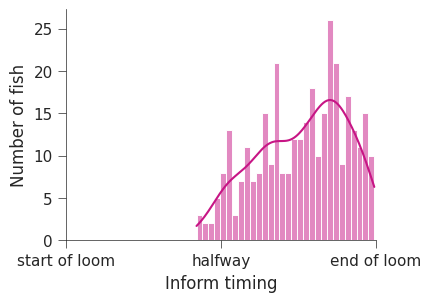

,global_inform_timing
0,NaN
1,0.900277
2,0.869806
3,0.880886
4,0.916805
...,...
371,0.604683
372,0.652893
373,0.651515
374,0.724518


In [ ]:
subpanel = 'S4e'

loom_threshold = 7
all_time_to_threshold = []

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  if fish_num <4: continue # restrict to groups of 4 or larger

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  for f in range(fish_num):
    f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

    if len(f_reach)==0: # never reach
      all_time_to_threshold.append(np.nan)
    else:
      all_time_to_threshold.append(f_reach[0]/loom_len) # percentage of trial length

# descriptive stats
print("N, 25, 50, and 75th percentile:")
data = all_time_to_threshold
print(f"(N={sum(~np.isnan(data))}) {np.nanpercentile(data, [25,50,75])}")

# plot
plt.figure(figsize=[4,3])
sns.histplot(all_time_to_threshold, bins=30, alpha=0.5, color='mediumvioletred', edgecolor='white', kde=True)
plt.xticks([0,0.5,1],['start of loom','halfway','end of loom']);
plt.xlabel('Inform timing'); plt.ylabel('Number of fish');
sns.despine(); plt.xlim(0,1)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {'global_inform_timing': all_time_to_threshold}
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S4f - inform timing PDF (by loom speed)

['#000000', '#333333', '#666666', '#999999']


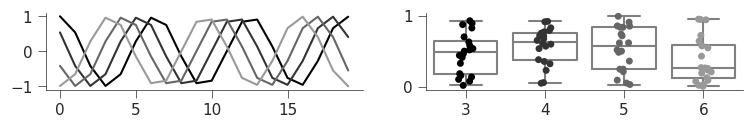

In [ ]:
group_names = [3,4,5,6]; group_num = len(group_names)
# get the RGBA from normalized colormap axis
viridis_colors = [cm.gist_gray(i/(group_num+1)) for i in range(0,group_num)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']
# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

In [ ]:
# some stats to calculate loom approach L/V
radius = 4.3 # cm
displacement = np.sqrt((30)**2+(15)**2)


Loom_dur = 3
N, 25, 50, and 75th percentile:
(N=118) [0.67355372 0.8030303  0.87811634]

Loom_dur = 4
N, 25, 50, and 75th percentile:
(N=81) [0.67219917 0.79002079 0.85123967]

Loom_dur = 5
N, 25, 50, and 75th percentile:
(N=67) [0.63214766 0.69752066 0.86237538]

Loom_dur = 6
N, 25, 50, and 75th percentile:
(N=67) [0.65426997 0.77272727 0.88897006]
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4f


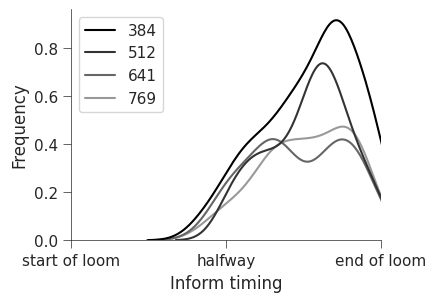

,L/V_384.60369212996386ms,L/V_512.8049228399518ms,L/V_641.0061535499398ms,L/V_769.2073842599277ms
0,NaN,0.887734,0.916805,0.713693
1,0.900277,0.621622,NaN,NaN
2,0.869806,0.590437,0.843594,0.933610
3,0.880886,0.528067,NaN,0.684647
4,0.986150,NaN,0.491694,NaN
...,...,...,...,...
121,0.845730,NaN,NaN,NaN
122,0.826446,NaN,NaN,NaN
123,0.749311,NaN,NaN,NaN
124,0.589532,NaN,NaN,NaN


In [ ]:
subpanel = 'S4f'
loom_speeds = [3,4,5,6]
speeds = [displacement/loom_dur for loom_dur in loom_speeds] # cm/s
SSRs = [(radius/speed)*1000 for speed in speeds] # ms

all_time_to_threshold = {int(SSR): [] for SSR in SSRs}

for ispd, spd in enumerate(loom_speeds):
  print(f'\nLoom_dur = {spd}')
  loom_threshold = 7

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
    if fish_num <4: continue # restrict to groups of 4 or larger
    if loom_dur != spd: continue
    speed = displacement/loom_dur # cm/s
    SSR = (radius/speed)*1000 # ms

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
    data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
    loom_subtend_angle = data['loom_subtend_angle']

    for f in range(fish_num):
      f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

      if len(f_reach)==0: # never reach
        all_time_to_threshold[int(SSR)].append(np.nan)
      else:
        all_time_to_threshold[int(SSR)].append(f_reach[0]/loom_len) # percentage of trial length

  # descriptive stats
  print("N, 25, 50, and 75th percentile:")
  data = all_time_to_threshold[int(SSR)]
  print(f"(N={sum(~np.isnan(data))}) {np.nanpercentile(data, [25,50,75])}")

# plot
plt.figure(figsize=[4,3])
sns.kdeplot(all_time_to_threshold, fill=False, palette=hex_colors)
plt.xlabel('Inform timing'); plt.ylabel('Frequency')
plt.xticks([0,0.5,1],['start of loom','halfway','end of loom']);
sns.despine(); plt.xlim(0,1)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for SSR in SSRs:
  series_dict[f'L/V_{SSR}ms'] = pd.Series(all_time_to_threshold[int(SSR)])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S4g - inform CDF by loom speeds

['#000000', '#333333', '#666666', '#999999']


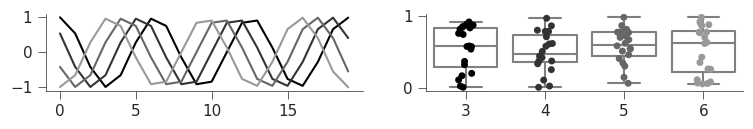

In [ ]:
group_names = [3,4,5,6]; group_num = len(group_names)
# get the RGBA from normalized colormap axis
viridis_colors = [cm.gist_gray(i/(group_num+1)) for i in range(0,group_num)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']
# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

In [ ]:
# some stats to calculate loom approach L/V
radius = 4.3 # cm
displacement = np.sqrt((30)**2+(15)**2)


Loom_dur = 3
Time reaching threshold (% of trial length):
N, [25, 50, 75 percentile], max
(N=126) [0.67355372 0.8030303  0.87811634], 0.9944903581267218
Reaching threshold probability:

time to reach 0.25, 0.50, 0.75 prbability (early, middle, late cutoffs)
0.6804407713498623
0.8209366391184573
0.9008264462809917

Loom_dur = 4
Time reaching threshold (% of trial length):
N, [25, 50, 75 percentile], max
(N=96) [0.67219917 0.79002079 0.85123967], 0.9937629937629938
Reaching threshold probability:

time to reach 0.25, 0.50, 0.75 prbability (early, middle, late cutoffs)
0.6859504132231405
0.8016528925619835
0.9173553719008265

Loom_dur = 5
Time reaching threshold (% of trial length):
N, [25, 50, 75 percentile], max
(N=72) [0.63214766 0.69752066 0.86237538], 0.9717138103161398
Reaching threshold probability:

time to reach 0.25, 0.50, 0.75 prbability (early, middle, late cutoffs)
0.6330578512396694
0.7421487603305785
0.8859504132231405

Loom_dur = 6
Time reaching threshold (% of trial leng

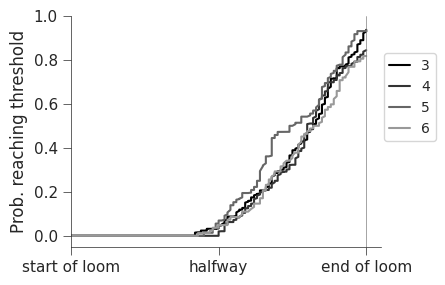

,loom_dur=3,loom_dur=4,loom_dur=5,loom_dur=6
0,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
721,0.920766,0.836954,0.930556,0.817073
722,0.928648,0.843750,0.930556,0.817073
723,0.936508,0.843750,0.930556,0.817073
724,0.936508,0.843750,0.930556,0.817073


In [ ]:
subpanel = 'S4g'
loom_speeds = [3,4,5,6]

loom_threshold = 7
ind_inform_time = {n:[] for n in loom_speeds}; ind_inform_cumulate = {n:[] for n in loom_speeds}
group_inform_time = {n:[] for n in loom_speeds}; group_inform_cumulate = {n:[] for n in loom_speeds}
early_cutoffs = {n:[] for n in loom_speeds}; late_cutoffs = {n:[] for n in loom_speeds}
middle_cutoffs = {n:[] for n in loom_speeds}

for ispd, spd in enumerate(loom_speeds):
  print(f'\nLoom_dur = {spd}')

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
    if fish_num <4: continue
    if loom_dur != spd: continue

    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed, f_bodylength_mm = data['f_speed']*scale, data['f_bodylength_mm']
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
    data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
    loom_subtend_angle = data['loom_subtend_angle']

    # get when fish reach critical loom angle
    reach_idx=[]; reach_array=[] # cumulative
    for f in range(fish_num):
      f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

      if len(f_reach)==0: # never reach
        ind_inform_time[spd].append(np.nan)
        ind_inform_cumulate[spd].append(np.full(loom_len,0))
        reach_idx.append(np.nan);
        reach_array.append(np.full(loom_len,0))
      else:
        ind_inform_time[spd].append(f_reach[0]/loom_len)
        ind_inform_cumulate[spd].append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))
        reach_idx.append(f_reach[0]);
        reach_array.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))

    group_inform_time[spd].append(np.nanmean(reach_idx)/loom_len)
    group_inform_cumulate[spd].append(np.nanmean(reach_array,axis=0))

  # individual level (across groups)
  print('Time reaching threshold (% of trial length):')
  print('N, [25, 50, 75 percentile], max')
  print(f'(N={len(ind_inform_time[spd])}) {np.nanpercentile(ind_inform_time[spd],[25,50,75])}, {np.nanmax(ind_inform_time[spd])}')

  # plot # with real time
  print('Reaching threshold probability:')
  arr, new_len = resample_to_max_length(ind_inform_cumulate[spd]) # warp to the same length
  print('\ntime to reach 0.25, 0.50, 0.75 prbability (early, middle, late cutoffs)')
  [print(f'{np.argmax(np.nanmean(arr,axis=0)>=pct)/new_len}') for pct in [0.25,0.5,0.75]]


  # make time_sec relative to loom for plotting
  rel_time = np.linspace(-spd,0,new_len); rel_sec = np.round(rel_time,2)

# plot together # time warpped
mean_ind_inform_cumulate = {n: np.nanmean(resample_to_max_length(ind_inform_cumulate[n])[0] ,axis=0) for n in loom_speeds}
tmp_arr = [];
[tmp_arr.append(mean_ind_inform_cumulate[spd]) for spd in loom_speeds]

plt.figure(figsize=[4,3])
arr, new_len = resample_to_max_length(tmp_arr) # warp to the same length

# make time_sec relative to loom for plotting
rel_time = np.linspace(0,1,new_len); rel_sec = np.round(rel_time,2)

for ispd, spd in enumerate(loom_speeds):
  plt.plot(rel_sec,arr[ispd],color=hex_colors[ispd],label=f'{spd}')
plt.axvline(1,lw=0.5,color='gray');
plt.xlim(0,1.05)
plt.ylim([-0.05,1]); plt.xticks([0,0.5,1],['start of loom','halfway','end of loom'])
plt.legend(bbox_to_anchor=(1,0.85),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
sns.despine(); plt.ylabel('Prob. reaching threshold'); # plt.xlabel('Time of reaching critical angle\n(fraction of trial length)');
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for ispd, spd in enumerate(loom_speeds):
  series_dict[f'loom_dur={spd}'] = pd.Series(arr[ispd])
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S4h - inform CDF by loom speeds, in sec

['#000000', '#333333', '#666666', '#999999']


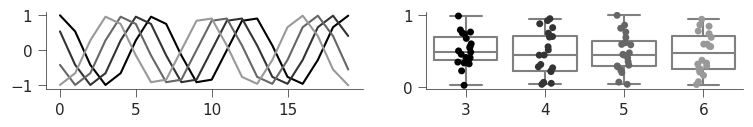

In [ ]:
group_names = [3,4,5,6]; group_num = len(group_names)
# get the RGBA from normalized colormap axis
viridis_colors = [cm.gist_gray(i/(group_num+1)) for i in range(0,group_num)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']
# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()


Loom_dur = 3
Time reaching threshold (% of trial length):
N, [25, 50, 75 percentile], max
(N=126) [0.67355372 0.8030303  0.87811634], 0.9944903581267218
Reaching threshold probability:

time to reach 0.25, 0.50, 0.75 prbability (early, middle, late cutoffs)
0.6804407713498623
0.8209366391184573
0.9008264462809917
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4h-3


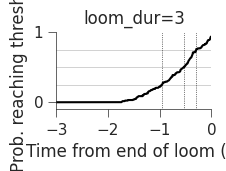

,loom_dur=3_1,loom_dur=3_2,loom_dur=3_3,loom_dur=3_4,loom_dur=3_5,loom_dur=3_6,loom_dur=3_7,loom_dur=3_8,loom_dur=3_9,loom_dur=3_10,...,loom_dur=3_117,loom_dur=3_118,loom_dur=3_119,loom_dur=3_120,loom_dur=3_121,loom_dur=3_122,loom_dur=3_123,loom_dur=3_124,loom_dur=3_125,loom_dur=3_126
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
359,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
360,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
361,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0



Loom_dur = 4
Time reaching threshold (% of trial length):
N, [25, 50, 75 percentile], max
(N=96) [0.67219917 0.79002079 0.85123967], 0.9937629937629938
Reaching threshold probability:

time to reach 0.25, 0.50, 0.75 prbability (early, middle, late cutoffs)
0.6859504132231405
0.8016528925619835
0.9173553719008265
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4h-4


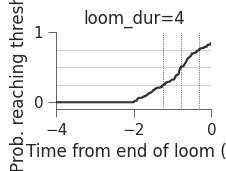

,loom_dur=4_1,loom_dur=4_2,loom_dur=4_3,loom_dur=4_4,loom_dur=4_5,loom_dur=4_6,loom_dur=4_7,loom_dur=4_8,loom_dur=4_9,loom_dur=4_10,...,loom_dur=4_87,loom_dur=4_88,loom_dur=4_89,loom_dur=4_90,loom_dur=4_91,loom_dur=4_92,loom_dur=4_93,loom_dur=4_94,loom_dur=4_95,loom_dur=4_96
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
480,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
481,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
482,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0



Loom_dur = 5
Time reaching threshold (% of trial length):
N, [25, 50, 75 percentile], max
(N=72) [0.63214766 0.69752066 0.86237538], 0.9717138103161398
Reaching threshold probability:

time to reach 0.25, 0.50, 0.75 prbability (early, middle, late cutoffs)
0.6330578512396694
0.7421487603305785
0.8859504132231405
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4h-5


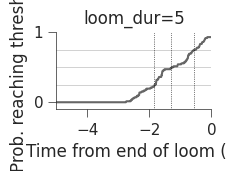

,loom_dur=5_1,loom_dur=5_2,loom_dur=5_3,loom_dur=5_4,loom_dur=5_5,loom_dur=5_6,loom_dur=5_7,loom_dur=5_8,loom_dur=5_9,loom_dur=5_10,...,loom_dur=5_63,loom_dur=5_64,loom_dur=5_65,loom_dur=5_66,loom_dur=5_67,loom_dur=5_68,loom_dur=5_69,loom_dur=5_70,loom_dur=5_71,loom_dur=5_72
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
601,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
602,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
603,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



Loom_dur = 6
Time reaching threshold (% of trial length):
N, [25, 50, 75 percentile], max
(N=82) [0.65426997 0.77272727 0.88897006], 0.9916897506925207
Reaching threshold probability:

time to reach 0.25, 0.50, 0.75 prbability (early, middle, late cutoffs)
0.6721763085399449
0.8209366391184573
0.9366391184573003
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4h-6


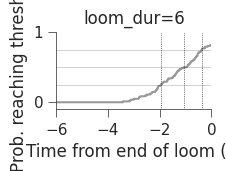

,loom_dur=6_1,loom_dur=6_2,loom_dur=6_3,loom_dur=6_4,loom_dur=6_5,loom_dur=6_6,loom_dur=6_7,loom_dur=6_8,loom_dur=6_9,loom_dur=6_10,...,loom_dur=6_73,loom_dur=6_74,loom_dur=6_75,loom_dur=6_76,loom_dur=6_77,loom_dur=6_78,loom_dur=6_79,loom_dur=6_80,loom_dur=6_81,loom_dur=6_82
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
722,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
723,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
724,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
subpanels = ['S4h', 'S4h', 'S4h', 'S4h']
loom_speeds = [3,4,5,6]

loom_threshold = 7
ind_inform_time = {n:[] for n in loom_speeds}; ind_inform_cumulate = {n:[] for n in loom_speeds}
group_inform_time = {n:[] for n in loom_speeds}; group_inform_cumulate = {n:[] for n in loom_speeds}
early_cutoffs = {n:[] for n in loom_speeds}; late_cutoffs = {n:[] for n in loom_speeds}
middle_cutoffs = {n:[] for n in loom_speeds}

for ispd, (subpanel, spd) in enumerate(zip(subpanels, loom_speeds)):
  print(f'\nLoom_dur = {spd}')

  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
    if fish_num <4: continue
    if loom_dur != spd: continue

    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed, f_bodylength_mm = data['f_speed']*scale, data['f_bodylength_mm']
    data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
    loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
    data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
    loom_subtend_angle = data['loom_subtend_angle']

    # get when fish reach critical loom angle
    reach_idx=[]; reach_array=[] # cumulative
    for f in range(fish_num):
      f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

      if len(f_reach)==0: # never reach
        ind_inform_time[spd].append(np.nan)
        ind_inform_cumulate[spd].append(np.full(loom_len,0))
        reach_idx.append(np.nan);
        reach_array.append(np.full(loom_len,0))
      else:
        ind_inform_time[spd].append(f_reach[0]/loom_len)
        ind_inform_cumulate[spd].append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))
        reach_idx.append(f_reach[0]);
        reach_array.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))

    group_inform_time[spd].append(np.nanmean(reach_idx)/loom_len)
    group_inform_cumulate[spd].append(np.nanmean(reach_array,axis=0))

  # individual level (across groups)
  print('Time reaching threshold (% of trial length):')
  print('N, [25, 50, 75 percentile], max')
  print(f'(N={len(ind_inform_time[spd])}) {np.nanpercentile(ind_inform_time[spd],[25,50,75])}, {np.nanmax(ind_inform_time[spd])}')

  # plot # with real time
  print('Reaching threshold probability:')
  plt.figure(figsize=[2,1])
  arr, new_len = resample_to_max_length(ind_inform_cumulate[spd]) # warp to the same length

  # make time_sec relative to loom for plotting
  rel_time = np.linspace(-spd,0,new_len); rel_sec = np.round(rel_time,2)

  plt.plot(rel_sec,np.nanmean(arr,axis=0),color=hex_colors[ispd])
  plt.axvline(0,lw=0.5,color='gray');

  for line in [0.25,0.5,0.75]:
    plt.axvline(np.argmax(np.nanmean(arr,axis=0)>=line)/new_len*(spd)-spd,color='black',linestyle=':',lw=0.5)
    plt.axhline(line,color='black',alpha=0.25,lw=0.5)
  print('\ntime to reach 0.25, 0.50, 0.75 prbability (early, middle, late cutoffs)')
  [print(f'{np.argmax(np.nanmean(arr,axis=0)>=pct)/new_len}') for pct in [0.25,0.5,0.75]]

  early_cutoffs[spd].append(np.argmax(np.nanmean(arr,axis=0)>=0.25)/new_len)
  middle_cutoffs[spd].append(np.argmax(np.nanmean(arr,axis=0)>=0.5)/new_len)
  late_cutoffs[spd].append(np.argmax(np.nanmean(arr,axis=0)>=0.75)/new_len)

  plt.xlim(-spd,0); plt.ylim([-0.1,1]); # plt.xticks([]);
  plt.title(f'loom_dur={spd}');
  sns.despine(); plt.ylabel('Prob. reaching threshold'); plt.xlabel('Time from end of loom (s)')
  print(figure_path+subpanel+f'-{spd}')
  plt.savefig(figure_path+subpanel+f'-{spd}.pdf', bbox_inches='tight')
  plt.show()

  # save source data into csv
  series_dict = {}
  for i, sample in enumerate(arr):
    series_dict[f'loom_dur={spd}_{i+1}'] = pd.Series(sample)
  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'-{spd}.csv', index=False)

# S4i - scatterplot of max angle and inform timing

In [ ]:
# calculate global time to threshold cutoffs
loom_threshold = 7

ind_fish_df = {}; ind_inform_cumulate = []
metrics = ['group_id','group_size', 'loom_dur', 'max_angle','ind_time', 'ind_status', 'group_time', 'group_status']
for metric in metrics: ind_fish_df[metric] = []

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  if fish_num <4: continue

  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  f_speed, f_bodylength_mm = data['f_speed']*scale, data['f_bodylength_mm']
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  for f in range(fish_num):
    ind_fish_df['group_id'].append(exp)
    ind_fish_df['group_size'].append(fish_num)
    ind_fish_df['loom_dur'].append(loom_dur)

    # get when fish reach critical loom angle
    f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

    # Maximum loom angle for this fish
    max_angle = np.nanmax(loom_subtend_angle[f])
    ind_fish_df['max_angle'].append(max_angle)

    # get when fish reach critical loom angle
    f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

    # assign ind status
    if len(f_reach) == 0: # never reach threshold
      ind_fish_df['ind_time'].append(np.nan)
      ind_inform_cumulate.append(np.full(loom_len,0))
      reach_array.append(np.full(loom_len,0))
    else:
      ind_fish_df['ind_time'].append(f_reach[0]/loom_len)
      ind_inform_cumulate.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))
      reach_array.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))

for key in ind_fish_df.keys():
  ind_fish_df[key] = np.array(ind_fish_df[key])

print('Time reaching threshold (% of trial length):')
print('N, [25, 50, 75 percentile], max')
print(f"(N={ind_fish_df['ind_time'].shape[0]}) {np.nanpercentile(ind_fish_df['ind_time'],[25,50,75])}")
cum_arr, new_len =resample_to_max_length(ind_inform_cumulate)
global_middle_cutoffs = np.argmax(np.nanmean(cum_arr,axis=0)>=0.5)/new_len
print(f'global middle cutoffs = {global_middle_cutoffs}')
global_early_cutoffs = np.argmax(np.nanmean(cum_arr,axis=0)>=0.25)/new_len
global_late_cutoffs = np.argmax(np.nanmean(cum_arr,axis=0)>=0.75)/new_len

Time reaching threshold (% of trial length):
N, [25, 50, 75 percentile], max
(N=376) [0.64864865 0.78239203 0.87257618]
global middle cutoffs = 0.8057851239669421



EARLY group N =  33
LATE group N =  29

early fish N =  188
late fish N =  188

early fish in EARLY group N =  153
early fish in LATE group N =  35
late fish in EARLY group N =  49
late fish in LATE group N =  139
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4i


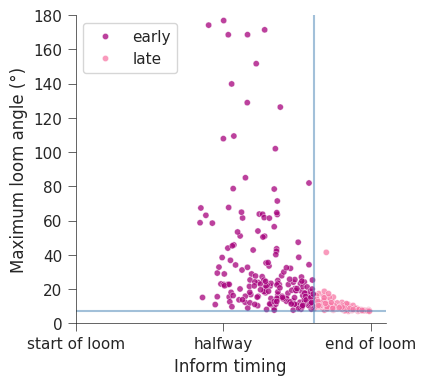

,max_angle,ind_time,ind_status
0,6.822676,NaN,late
1,10.542230,0.900277,late
2,12.155791,0.869806,late
3,9.945738,0.880886,late
4,9.490534,0.916805,late
...,...,...,...
371,21.837672,0.604683,early
372,18.696648,0.652893,early
373,35.451904,0.651515,early
374,25.731686,0.724518,early


In [ ]:
# assign early late based on global cutoffs
subpanel = 'S4i'
loom_threshold = 7

ind_fish_df = {};
metrics = ['group_id','group_size', 'loom_dur', 'max_angle','ind_time', 'ind_status', 'group_time', 'group_status']
for metric in metrics: ind_fish_df[metric] = []

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  if fish_num <4: continue # restrict to groups of 4 or larger

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  reach_array=[] # cumulative
  for f in range(fish_num):
    ind_fish_df['group_id'].append(exp)
    ind_fish_df['group_size'].append(fish_num)
    ind_fish_df['loom_dur'].append(loom_dur)

    # Maximum loom angle for this fish
    max_angle = np.nanmax(loom_subtend_angle[f])
    ind_fish_df['max_angle'].append(max_angle)

    # get when fish reach critical loom angle
    f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

    # assign ind status
    if len(f_reach) == 0: # never reach threshold
      ind_fish_df['ind_time'].append(np.nan)
      ind_fish_df['ind_status'].append('late')
      reach_array.append(np.full(loom_len,0))
    else:
      ind_fish_df['ind_time'].append(f_reach[0]/loom_len)
      reach_array.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))
      if f_reach[0]/loom_len < global_middle_cutoffs:
        ind_fish_df['ind_status'].append('early')
      else:
        ind_fish_df['ind_status'].append('late')

  # assign group status
  group_inform_time = np.argmax(np.nanmean(reach_array,axis=0)>=0.5)
  [ind_fish_df['group_time'].append(group_inform_time/loom_len) for f in range(fish_num)]
  if group_inform_time/loom_len < global_middle_cutoffs:
    [ind_fish_df['group_status'].append('early') for f in range(fish_num)]
  else:
    [ind_fish_df['group_status'].append('late') for f in range(fish_num)]

for key in ind_fish_df.keys():
  ind_fish_df[key] = np.array(ind_fish_df[key])

print('\nEARLY group N = ', len(np.unique(ind_fish_df['group_id'][ind_fish_df["group_status"]=="early"])))
print('LATE group N = ', len(np.unique(ind_fish_df['group_id'][ind_fish_df["group_status"]=="late"])))

print('\nearly fish N = ', np.sum(ind_fish_df["ind_status"]=="early"))
print('late fish N = ', np.sum(ind_fish_df["ind_status"]=="late"))

print('\nearly fish in EARLY group N = ', np.sum((ind_fish_df['ind_status']=='early')*(ind_fish_df['group_status']=='early')))
print('early fish in LATE group N = ', np.sum((ind_fish_df['ind_status']=='early')*(ind_fish_df['group_status']=='late')))
print('late fish in EARLY group N = ', np.sum((ind_fish_df['ind_status']=='late')*(ind_fish_df['group_status']=='early')))
print('late fish in LATE group N = ', np.sum((ind_fish_df['ind_status']=='late')*(ind_fish_df['group_status']=='late')))

# global cutoff plot
hex_colorz = ['#a6017c', '#f778a6']; labels = ['early','late']

# plot
plt.figure(figsize=[4, 4])
sns.scatterplot(x=ind_fish_df['ind_time'], y=ind_fish_df['max_angle'], s=20, alpha=0.75,\
                hue=ind_fish_df['ind_status'], palette=hex_colorz,hue_order=labels)
plt.axhline(y=loom_threshold, color='steelblue', alpha=0.5)
plt.axvline(x=global_middle_cutoffs, color='steelblue', alpha=0.5)
plt.ylim(0,180); plt.xlim(0.25,1.05)
plt.xticks([0,0.5,1],['start of loom','halfway','end of loom'])
plt.xlabel('Inform timing'); plt.ylabel('Maximum loom angle (°)')
sns.despine()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
series_dict['max_angle'] = pd.Series(ind_fish_df['max_angle'])
series_dict['ind_time'] = pd.Series(ind_fish_df['ind_time'])
series_dict['ind_status'] = pd.Series(ind_fish_df['ind_status'])
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

## S4j - late fish speeds by loom speed

In [ ]:
# some stats to calculate loom approach L/V
radius = 4.3 # cm
displacement = np.sqrt((30)**2+(15)**2)

In [ ]:
# assign early late based on global cutoffs
loom_threshold = 7
bin_num = 20
ind_fish_df = {};
metrics = ['group_id','group_size', 'loom_dur', 'max_angle','ind_time', 'ind_status', 'group_time', 'group_status',\
           'speed_before_loom']
for metric in metrics: ind_fish_df[metric] = []

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  if fish_num <4: continue # restrict to groups of 4 or larger
  # calculate loom kinematics
  speed = displacement/loom_dur # cm/s
  SSR = (radius/speed)*1000 # ms

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  reach_array=[] # cumulative
  for f in range(fish_num):
    ind_fish_df['group_id'].append(exp)
    ind_fish_df['group_size'].append(fish_num)
    ind_fish_df['loom_dur'].append(SSR)

    # bin the speed into 10% time of loom duration
    f_speed_bins = np.array_split(f_speed[f][loom_off-loom_len:loom_off],bin_num)
    ind_fish_df['speed_before_loom'].append([np.nanmean(bin) for bin in f_speed_bins])

    # Maximum loom angle for this fish
    max_angle = np.nanmax(loom_subtend_angle[f])
    ind_fish_df['max_angle'].append(max_angle)

    # get when fish reach critical loom angle
    f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

    # assign ind status
    if len(f_reach) == 0: # never reach threshold
      ind_fish_df['ind_time'].append(np.nan)
      ind_fish_df['ind_status'].append('late')
      reach_array.append(np.full(loom_len,0))
    else:
      ind_fish_df['ind_time'].append(f_reach[0]/loom_len)
      reach_array.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))
      if f_reach[0]/loom_len < global_middle_cutoffs:
        ind_fish_df['ind_status'].append('early')
      else:
        ind_fish_df['ind_status'].append('late')

  # assign group status
  group_inform_time = np.argmax(np.nanmean(reach_array,axis=0)>=0.5)
  [ind_fish_df['group_time'].append(group_inform_time/loom_len) for f in range(fish_num)]
  if group_inform_time/loom_len < global_middle_cutoffs:
    [ind_fish_df['group_status'].append('early') for f in range(fish_num)]
  else:
    [ind_fish_df['group_status'].append('late') for f in range(fish_num)]

for key in ind_fish_df.keys():
  # if key == 'speed_before_loom': continue
  ind_fish_df[key] = np.array(ind_fish_df[key])

print('\nEARLY group N = ', len(np.unique(ind_fish_df['group_id'][ind_fish_df["group_status"]=="early"])))
print('LATE group N = ', len(np.unique(ind_fish_df['group_id'][ind_fish_df["group_status"]=="late"])))

print('\nearly fish N = ', np.sum(ind_fish_df["ind_status"]=="early"))
print('late fish N = ', np.sum(ind_fish_df["ind_status"]=="late"))

print('\nearly fish in EARLY group N = ', np.sum((ind_fish_df['ind_status']=='early')*(ind_fish_df['group_status']=='early')))
print('early fish in LATE group N = ', np.sum((ind_fish_df['ind_status']=='early')*(ind_fish_df['group_status']=='late')))
print('late fish in EARLY group N = ', np.sum((ind_fish_df['ind_status']=='late')*(ind_fish_df['group_status']=='early')))
print('late fish in LATE group N = ', np.sum((ind_fish_df['ind_status']=='late')*(ind_fish_df['group_status']=='late')))
print('naive fish in EARLY group N = ', np.sum(np.isnan(ind_fish_df['ind_time'])*(ind_fish_df['group_status']=='early')))
print('naive fish in LATE group N = ', np.sum(np.isnan(ind_fish_df['ind_time'])*(ind_fish_df['group_status']=='late')))


EARLY group N =  33
LATE group N =  29

early fish N =  188
late fish N =  188

early fish in EARLY group N =  153
early fish in LATE group N =  35
late fish in EARLY group N =  49
late fish in LATE group N =  139
naive fish in EARLY group N =  10
naive fish in LATE group N =  33


In [ ]:
loom_speeds = [lsp for lsp in np.unique(sorted(ind_fish_df['loom_dur']))]
loom_speeds

In [ ]:
hex_colorz = ['#a6017c', '#f778a6'];
categories = ['early','late']

# make time_sec relative to tap for plotting
pre = np.linspace(0,1,bin_num); rel_time = pre; rel_sec = np.round(rel_time,2)

# take the two faster loom speeds
filter = (ind_fish_df['loom_dur'] == loom_speeds[0]) + (ind_fish_df['loom_dur'] == loom_speeds[1])
# masks
early_fish = (ind_fish_df['ind_status'] == 'late')*(ind_fish_df['group_status'] == 'early')*filter
late_fish = (ind_fish_df['ind_status'] == 'late')*(ind_fish_df['group_status'] == 'late')*filter

early_speeds = ind_fish_df['speed_before_loom'][early_fish]
late_speeds = ind_fish_df['speed_before_loom'][late_fish]

print('N in early group & late group', np.sum(early_fish), np.sum(late_fish))

subpanel = 'S4j - fast'
# plot
plt.figure(figsize=[3, 3])
plt.plot(rel_sec, np.nanmean(early_speeds,axis=0),color=hex_colorz[0],label='early')
plt.fill_between(rel_sec,np.nanmean(early_speeds,axis=0)-stats.sem(early_speeds,axis=0),\
                 np.nanmean(early_speeds,axis=0)+stats.sem(early_speeds,axis=0),color=hex_colorz[0],alpha=0.25,lw=0)
plt.plot(rel_sec, np.nanmean(late_speeds,axis=0),color=hex_colorz[1],label='late')
plt.fill_between(rel_sec,np.nanmean(late_speeds,axis=0)-stats.sem(late_speeds,axis=0),\
                 np.nanmean(late_speeds,axis=0)+stats.sem(late_speeds,axis=0),color=hex_colorz[1],alpha=0.25,lw=0)
plt.legend(bbox_to_anchor=(1,0.85),handlelength=1.5)
plt.axvline(0.5,color='gray'); plt.ylim(15,50); plt.xlim(0.5,1)
plt.xticks([0.5,1],['halfway','end of loom'])
plt.ylabel('Speed (mm/s)')
sns.despine(); plt.title(f'Late fish during fast loom');
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, s in enumerate(early_speeds): series_dict[f'early_fish_{i+1}_fast_loom'] = pd.Series(s)
for i, s in enumerate(late_speeds): series_dict[f'late_fish_{i+1}_fast_loom'] = pd.Series(s)

# take the two slower loom speeds
filter = (ind_fish_df['loom_dur'] == loom_speeds[2]) + (ind_fish_df['loom_dur'] == loom_speeds[3])
# masks
early_fish = (ind_fish_df['ind_status'] == 'late')*(ind_fish_df['group_status'] == 'early')*filter
late_fish = (ind_fish_df['ind_status'] == 'late')*(ind_fish_df['group_status'] == 'late')*filter

early_speeds = ind_fish_df['speed_before_loom'][early_fish]
late_speeds = ind_fish_df['speed_before_loom'][late_fish]

print('N in early group & late group', np.sum(early_fish), np.sum(late_fish))

subpanel = 'S4j - slow'
# plot
plt.figure(figsize=[3, 3])
plt.plot(rel_sec, np.nanmean(early_speeds,axis=0),color=hex_colorz[0],label='early')
plt.fill_between(rel_sec,np.nanmean(early_speeds,axis=0)-stats.sem(early_speeds,axis=0),\
                 np.nanmean(early_speeds,axis=0)+stats.sem(early_speeds,axis=0),color=hex_colorz[0],alpha=0.25,lw=0)
plt.plot(rel_sec, np.nanmean(late_speeds,axis=0),color=hex_colorz[1],label='late')
plt.fill_between(rel_sec,np.nanmean(late_speeds,axis=0)-stats.sem(late_speeds,axis=0),\
                 np.nanmean(late_speeds,axis=0)+stats.sem(late_speeds,axis=0),color=hex_colorz[1],alpha=0.25,lw=0)
plt.legend(bbox_to_anchor=(1,0.85),handlelength=1.5)
plt.axvline(0.5,color='gray'); plt.ylim(15,50); plt.xlim(0.5,1)
plt.xticks([0.5,1],['halfway','end of loom'])
plt.ylabel('Speed (mm/s)')
sns.despine(); plt.title(f'Late fish during slow loom');
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# save
for i, s in enumerate(early_speeds): series_dict[f'early_fish_{i+1}_slow_loom'] = pd.Series(s)
for i, s in enumerate(late_speeds): series_dict[f'late_fish_{i+1}_slow_loom'] = pd.Series(s)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S4k - num of early neighbor

In [ ]:
# calculate global cutoffs
# calculate global time to threshold cutoffs
loom_threshold = 7

ind_fish_df = {}; ind_inform_cumulate = []
metrics = ['group_id','group_size', 'loom_dur', 'max_angle','ind_time', 'ind_status', 'group_time', 'group_status']
for metric in metrics: ind_fish_df[metric] = []

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  if fish_num <4: continue

  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  f_speed, f_bodylength_mm = data['f_speed']*scale, data['f_bodylength_mm']
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  reach_idx=[]; reach_array=[]
  for f in range(fish_num):
    ind_fish_df['group_id'].append(exp)
    ind_fish_df['group_size'].append(fish_num)
    ind_fish_df['loom_dur'].append(loom_dur)

    # get when fish reach critical loom angle
    f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

    # Maximum loom angle for this fish
    max_angle = np.nanmax(loom_subtend_angle[f])
    ind_fish_df['max_angle'].append(max_angle)

    # get when fish reach critical loom angle
    f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

    # assign ind status
    if len(f_reach) == 0: # never reach threshold
      ind_fish_df['ind_time'].append(np.nan)
      ind_inform_cumulate.append(np.full(loom_len,0))
      reach_array.append(np.full(loom_len,0))
    else:
      ind_fish_df['ind_time'].append(f_reach[0]/loom_len)
      ind_inform_cumulate.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))
      reach_array.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))

for key in ind_fish_df.keys():
  ind_fish_df[key] = np.array(ind_fish_df[key])

print('Time reaching threshold (% of trial length):')
print('N, [25, 50, 75 percentile], max')
print(f"(N={ind_fish_df['ind_time'].shape[0]}) {np.nanpercentile(ind_fish_df['ind_time'],[25,50,75])}")
cum_arr, new_len =resample_to_max_length(ind_inform_cumulate)
global_middle_cutoffs = np.argmax(np.nanmean(cum_arr,axis=0)>=0.5)/new_len
print(f'global middle cutoffs = {global_middle_cutoffs}')
global_early_cutoffs = np.argmax(np.nanmean(cum_arr,axis=0)>=0.25)/new_len
global_late_cutoffs = np.argmax(np.nanmean(cum_arr,axis=0)>=0.75)/new_len

Time reaching threshold (% of trial length):
N, [25, 50, 75 percentile], max
(N=376) [0.64864865 0.78239203 0.87257618]
global middle cutoffs = 0.8057851239669421


In [ ]:
# assign early late based on global cutoffs
loom_threshold = 7
bin_num = 20
ind_fish_df = {};
metrics = ['group_id','group_size', 'loom_dur', 'max_angle','ind_time', 'ind_status', 'group_time', 'group_status','speed_before_loom']
for metric in metrics: ind_fish_df[metric] = []

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]; loom_dur = metadata.loom_dur[exp]
  if fish_num <4: continue # restrict to groups of 4 or larger

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fps, scale = data['fps'], data['scale']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len
  data = np.load(load_path + 'lev2_loom2fish.npz', allow_pickle=True)
  loom_subtend_angle = data['loom_subtend_angle']

  reach_array=[] # cumulative
  for f in range(fish_num):
    ind_fish_df['group_id'].append(exp)
    ind_fish_df['group_size'].append(fish_num)
    ind_fish_df['loom_dur'].append(loom_dur)

    # bin the speed into 10% time of loom duration
    f_speed_bins = np.array_split(f_speed[f][loom_off-loom_len:loom_off],bin_num)
    ind_fish_df['speed_before_loom'].append([np.nanmean(bin) for bin in f_speed_bins])

    # Maximum loom angle for this fish
    max_angle = np.nanmax(loom_subtend_angle[f])
    ind_fish_df['max_angle'].append(max_angle)

    # get when fish reach critical loom angle
    f_reach = np.where(loom_subtend_angle[f]>=loom_threshold)[0]

    # assign ind status
    if len(f_reach) == 0: # never reach threshold
      ind_fish_df['ind_time'].append(np.nan)
      ind_fish_df['ind_status'].append('late')
      reach_array.append(np.full(loom_len,0))
    else:
      ind_fish_df['ind_time'].append(f_reach[0]/loom_len)
      reach_array.append(np.concatenate([np.full(f_reach[0],0),np.full(loom_len-f_reach[0],1)]))
      if f_reach[0]/loom_len < global_middle_cutoffs:
        ind_fish_df['ind_status'].append('early')
      else:
        ind_fish_df['ind_status'].append('late')

  # assign group status
  group_inform_time = np.argmax(np.nanmean(reach_array,axis=0)>=0.5)
  [ind_fish_df['group_time'].append(group_inform_time/loom_len) for f in range(fish_num)]
  if group_inform_time/loom_len < global_middle_cutoffs:
    [ind_fish_df['group_status'].append('early') for f in range(fish_num)]
  else:
    [ind_fish_df['group_status'].append('late') for f in range(fish_num)]

for key in ind_fish_df.keys():
  # if key == 'speed_before_loom': continue
  ind_fish_df[key] = np.array(ind_fish_df[key])

print('\nEARLY group N = ', len(np.unique(ind_fish_df['group_id'][ind_fish_df["group_status"]=="early"])))
print('LATE group N = ', len(np.unique(ind_fish_df['group_id'][ind_fish_df["group_status"]=="late"])))

print('\nearly fish N = ', np.sum(ind_fish_df["ind_status"]=="early"))
print('late fish N = ', np.sum(ind_fish_df["ind_status"]=="late"))

print('\nearly fish in EARLY group N = ', np.sum((ind_fish_df['ind_status']=='early')*(ind_fish_df['group_status']=='early')))
print('early fish in LATE group N = ', np.sum((ind_fish_df['ind_status']=='early')*(ind_fish_df['group_status']=='late')))
print('late fish in EARLY group N = ', np.sum((ind_fish_df['ind_status']=='late')*(ind_fish_df['group_status']=='early')))
print('late fish in LATE group N = ', np.sum((ind_fish_df['ind_status']=='late')*(ind_fish_df['group_status']=='late')))
print('naive fish in EARLY group N = ', np.sum(np.isnan(ind_fish_df['ind_time'])*(ind_fish_df['group_status']=='early')))
print('naive fish in LATE group N = ', np.sum(np.isnan(ind_fish_df['ind_time'])*(ind_fish_df['group_status']=='late')))


EARLY group N =  33
LATE group N =  29

early fish N =  188
late fish N =  188

early fish in EARLY group N =  153
early fish in LATE group N =  35
late fish in EARLY group N =  49
late fish in LATE group N =  139
naive fish in EARLY group N =  10
naive fish in LATE group N =  33


In [ ]:
early_fish_counts = []; early_fish_pcts = []; group_speed_before_loom = []
for gp in np.unique(ind_fish_df['group_id']):
  early_fish_count = np.sum((ind_fish_df['group_id']==gp)*(ind_fish_df['ind_status']=='early'))
  gs = ind_fish_df['group_size'][ind_fish_df['group_id']==gp]

  # need to exclude all early fish groups
  if early_fish_count==gs[0]: continue

  early_fish_counts.append(early_fish_count)
  early_fish_pct = early_fish_count/gs[0]
  early_fish_pcts.append(early_fish_pct)
  # take only the late informed fish
  filter = (ind_fish_df['group_id']==gp)*(ind_fish_df['ind_status']=='late')
  speeds = ind_fish_df['speed_before_loom'][filter]
  group_speed_before_loom.append(np.nanmean(speeds,axis=0))
  # break
early_fish_counts = np.array(early_fish_counts); early_fish_pcts = np.array(early_fish_pcts)
group_speed_before_loom = np.array(group_speed_before_loom)
# print(len(np.unique(ind_fish_df['group_id'])), len(early_fish_counts), len(early_fish_pcts), len(group_speed_before_loom))

['#000000', '#f667a0', '#e5449a', '#cd238e', '#ac017d', '#8a0179', '#690072', '#49006a']
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S4k


/tmp/ipykernel_10046/3151444199.py:23: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);


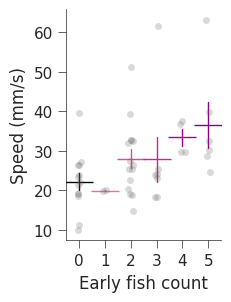

Ns, means, and  sems for data:
0: (N=13) 22.232, 2.070
1: (N=2) 19.891, 0.172
2: (N=15) 28.060, 2.388
3: (N=7) 27.844, 5.711
4: (N=4) 33.441, 2.132
5: (N=6) 36.541, 5.719

Normality test (Shapiro-Wilk):
Group 0: W = 0.928, p = 0.321
Group 1: W = nan, p = nan
Group 2: W = 0.929, p = 0.264
Group 3: W = 0.622, p = 0.000
Group 4: W = 0.777, p = 0.067
Group 5: W = 0.809, p = 0.070
not all groups are normally distributed → use nonparametric test.

Kruskal-Wallis H-test: H = 13.908, p = 1.6207111801e-02

Dunn's post hoc test with bonferroni correction:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
          1         2    3         4         5         6
1  1.000000  1.000000  1.0  1.000000  0.187800  0.077994
2  1.000000  1.000000  1.0  1.000000  0.528874  0.446092
3  1.000000  1.000000  1.0  1.000000  1.000000  1.000000
4  1.000000  1.000000  1.0  1.000000  0.732904  0.495355
5  0.187800  0.528874  1.0  0.732904  1.000000  1.000000
6  0.077994  0.446092  1.0

/tmp/ipykernel_10046/3151444199.py:42: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = stats.shapiro(data)


,early_fish_count_0,early_fish_count_1,early_fish_count_2,early_fish_count_3,early_fish_count_4,early_fish_count_5
0,10.031975,20.062609,20.313572,18.322018,36.702350,63.214989
1,18.977497,19.719072,32.730462,25.402193,37.541447,32.611240
2,21.260734,NaN,25.454797,24.193144,29.773516,30.335129
3,11.311698,NaN,14.857313,61.512306,29.745622,39.837025
4,22.222293,NaN,18.794486,24.004435,NaN,24.594721
5,23.959259,NaN,26.316912,18.451398,NaN,28.651350
6,27.068424,NaN,32.538681,23.020653,NaN,NaN
7,26.541548,NaN,25.364647,NaN,NaN,NaN
8,26.339663,NaN,22.557333,NaN,NaN,NaN
9,19.457040,NaN,39.232409,NaN,NaN,NaN


In [ ]:
subpanel = 'S4k'
# RGB hex values - per early fish count
group_num = len([2,3,4,5])
# get the RGBA from normalized colormap axis
viridis_colors = [cm.RdPu(i/(group_num+5)) for i in range(6,group_num+6)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
hex_colors.insert(0,'#000000') # different color for 0
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']

# make time in trial fraction
pre = np.linspace(0,1,bin_num); rel_time = pre; rel_sec = np.round(rel_time,2)

# get last 20% of speed
group_values = {n: [] for n in sorted(np.unique(early_fish_counts))[:-2]}
for i, gp in enumerate(sorted(np.unique(early_fish_counts))[:-2]):
  filter = (early_fish_counts==gp)
  speeds = group_speed_before_loom[filter]
  sp = np.nanmean(speeds[:,-int(bin_num*0.2):],axis=1)
  group_values[gp] = sp

plt.figure(figsize=[2,3])
sns.stripplot(data=group_values,color='dimgray',alpha=0.25)
sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.ylabel('Speed (mm/s)'); plt.xlabel('Early fish count');
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf', bbox_inches='tight')
plt.show()

# stats
categories = sorted(np.unique(early_fish_counts))
groups = group_values.keys()
summary_data = group_values.values()
print("Ns, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(f'{categories[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups);
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    # model = smf.ols(summary_data, groups).fit()
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit() # Changed this line
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)

# save source data into csv
series_dict = {}
for i, gp in enumerate(sorted(np.unique(early_fish_counts_comb))):
  col_name = f'early_fish_count_{gp}'
  series_dict[col_name] = pd.Series(group_values_comb[gp])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)